# Capstone 2: Business Analysis with Python
# EmporiUm Sales Territory Analysis — Northeast Region

**Analyst:** Mohamed Mouatakid  
**Week:** 8  

# Sales Territories Being Analyzed:
| Territory         | State            | Territory Manager |
|-----------|-------|------------------|
| Sales Territory 1 | Maine            | Erbayne Middleton |
| Sales Territory 2 | Maryland         | Shruti Reddy |


# Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Step 2 — Load and Inspect Data

In [7]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.columns = customer_list.columns.str.strip()
customer_list.info()
customer_list.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cust_id      521 non-null    int64 
 1   date         521 non-null    object
 2   time         521 non-null    object
 3   name         521 non-null    object
 4   email        521 non-null    object
 5   phone        520 non-null    object
 6   sms-opt-out  520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [8]:
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()
product_categories.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [9]:
products = pd.read_csv('Products.csv')
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()
store_detail.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [10]:
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()
store_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


# Core Marketing Analysis

# Question 1 — Territory Managers & Store Information

In [12]:
my_states = ['Maine', 'Maryland']
my_stores = store_detail[store_detail['State'].isin(my_states)].copy()

for state in my_states:
    state_stores = my_stores[my_stores['State'] == state]
    manager = state_stores['Territory Manager'].iloc[0]
    print(f"{'='*50}")
    print(f"  Territory: {state}")
    print(f"  Territory Manager: {manager}")
    print(f"{'='*50}")
    print(state_stores[['Store ID', 'Store Location']].to_string(index=False))
    print()

  Territory: Maine
  Territory Manager: Erbayne Middleton
 Store ID Store Location
      818         Bangor
      819     Bar Harbor
      820  Kennebunkport
      821       Lewiston
      822          Orono
      823 South Portland

  Territory: Maryland
  Territory Manager: Shruti Reddy
 Store ID      Store Location
      731           Annapolis
      732          Back River
      733           Baltimore
      734          Germantown
      735              Howard
      736       North Harford
      737           Parkville
      738 Queen Anne's County
      739             Ridgely



# Question 2 — Monthly Total Revenue
What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

In [13]:
# Get store IDs for our territories
my_store_ids = my_stores['Store ID'].tolist()

# Filter sales to our territory stores only
my_sales = store_sales[store_sales['Store ID'].isin(my_store_ids)].copy()

# Parse transaction date and extract month
my_sales['Transaction Date'] = pd.to_datetime(my_sales['Transaction Date'])
my_sales['Month'] = my_sales['Transaction Date'].dt.to_period('M')

# Merge with store details to know which state each sale belongs to
my_sales_detail = my_sales.merge(
    my_stores[['Store ID', 'Store Location', 'State', 'Territory Manager']],
    on='Store ID'
)

print(f"Total transactions in our territories: {len(my_sales_detail):,}")
print(f"Date range: {my_sales['Transaction Date'].min().date()} to {my_sales['Transaction Date'].max().date()}")

Total transactions in our territories: 102,709
Date range: 2022-01-01 to 2025-12-31


In [14]:
# Calculate monthly revenue per territory
monthly_revenue = my_sales_detail.groupby(
    ['State', 'Month'])['Sale Amount'].sum().reset_index()

# Display monthly revenue for each territory
for state in my_states:
    df = monthly_revenue[monthly_revenue['State'] == state].sort_values('Month')
    print(f"\n{'='*45}")
    print(f"  {state} — Monthly Revenue")
    print(f"{'='*45}")
    print(df[['Month', 'Sale Amount']].to_string(index=False))
    print(f"\n  Total Revenue: ${df['Sale Amount'].sum():,.2f}")
    print(f"  Average Monthly: ${df['Sale Amount'].mean():,.2f}")
    print(f"  Best Month:  {df.loc[df['Sale Amount'].idxmax(), 'Month']} — ${df['Sale Amount'].max():,.2f}")
    print(f"  Worst Month: {df.loc[df['Sale Amount'].idxmin(), 'Month']} — ${df['Sale Amount'].min():,.2f}")


  Maine — Monthly Revenue
  Month  Sale Amount
2022-01     15700.31
2022-02     21008.29
2022-03     23173.23
2022-04     20169.19
2022-05     22631.11
2022-06     31573.93
2022-07     19371.11
2022-08     27979.07
2022-09     27393.30
2022-10     24947.09
2022-11     19783.08
2022-12     25345.23
2023-01     41331.95
2023-02     37650.30
2023-03     36162.92
2023-04     35875.41
2023-05     26201.22
2023-06     30183.66
2023-07     44731.17
2023-08     42202.08
2023-09     44862.59
2023-10     34905.29
2023-11     35428.88
2023-12     41279.32
2024-01     43881.68
2024-02     31494.48
2024-03     36311.69
2024-04     25764.94
2024-05     31426.20
2024-06     43488.63
2024-07     42202.08
2024-08     46505.54
2024-09     33262.34
2024-10     36520.57
2024-11     40187.63
2024-12     41331.95
2025-01     45308.75
2025-02     51793.28
2025-03     45762.66
2025-04     63103.49
2025-05     46499.27
2025-06     57053.98
2025-07     59531.02
2025-08     61070.43
2025-09     48485.08
2025-10


The data covers the full period from **January 2022 to December 2025** (48 months).

                | Maine         | Maryland |
| Total Revenue | $1,877,249.75 | $11,451,615.09 |
| Average Monthly Revenue | $39,109.37 | $238,575.31 |
| Best Month | Oct 2025 — $93,456.68 | Oct 2025 — $359,699.69 |
| Worst Month | Jan 2022 — $15,700.31 | Sep 2022 — $158,952.74 |

**Key Observations:**
- Maryland generates significantly more revenue than Maine — roughly **6x more** per month on average
- Both territories show a clear **upward trend** from 2022 to 2025
- Both territories peaked in **October 2025**
- Maine started very low in early 2022 but grew consistently year over year

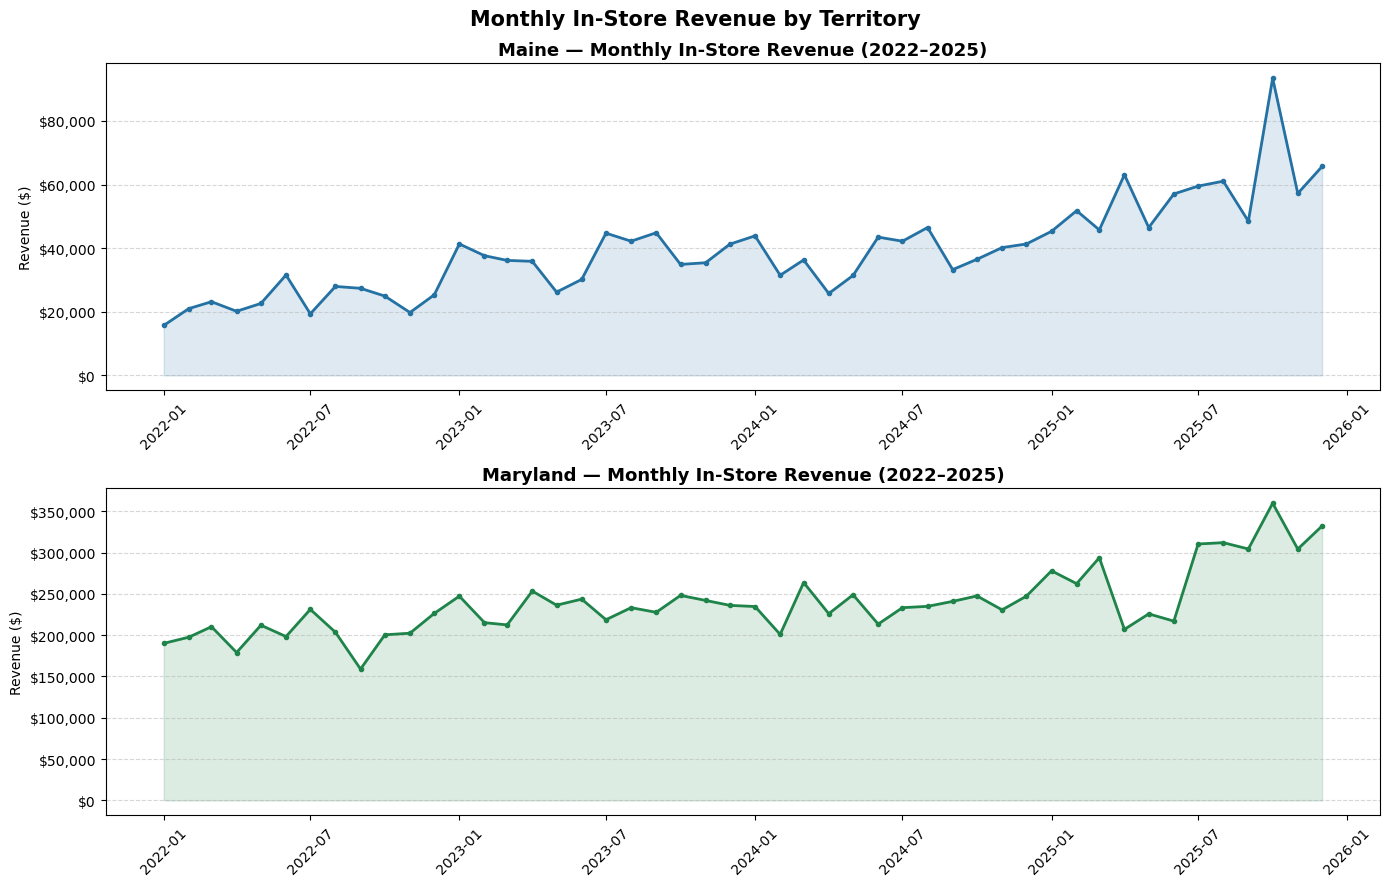

Chart saved!


In [16]:
# Chart 1: Monthly Revenue Over Time by Territory
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
colors = {'Maine': '#2471A3', 'Maryland': '#1E8449'}

for i, state in enumerate(my_states):
    df = monthly_revenue[monthly_revenue['State'] == state].sort_values('Month')
    df['Month_dt'] = df['Month'].dt.to_timestamp()
    
    axes[i].plot(df['Month_dt'], df['Sale Amount'], 
                 color=colors[state], linewidth=2, marker='o', markersize=3)
    axes[i].fill_between(df['Month_dt'], df['Sale Amount'], 
                         alpha=0.15, color=colors[state])
    axes[i].set_title(f'{state} — Monthly In-Store Revenue (2022–2025)', 
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Revenue ($)', fontsize=10)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly In-Store Revenue by Territory', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved!")

# Question 3 — Store Performance Rankings

In [17]:
# Calculate total revenue and transactions per store
store_revenue = my_sales_detail.groupby(
    ['State', 'Store ID', 'Store Location'])['Sale Amount'].agg(
    Total_Revenue='sum',
    Num_Transactions='count'
).reset_index()

# Calculate average transaction value per store
store_revenue['Avg_Transaction'] = (store_revenue['Total_Revenue'] / 
                                    store_revenue['Num_Transactions'])

# Rank stores by revenue within each territory
store_revenue = store_revenue.sort_values(
    ['State', 'Total_Revenue'], ascending=[True, False])

# Display rankings
for state in my_states:
    df = store_revenue[store_revenue['State'] == state].reset_index(drop=True)
    df.index += 1
    print(f"\n{'='*65}")
    print(f"  {state} — Store Performance Rankings")
    print(f"{'='*65}")
    for idx, row in df.iterrows():
        print(f"  #{idx}  Store {row['Store ID']} — {row['Store Location']}")
        print(f"      Revenue: ${row['Total_Revenue']:>12,.2f}  |  "
              f"Transactions: {row['Num_Transactions']:,}  |  "
              f"Avg: ${row['Avg_Transaction']:.2f}")


  Maine — Store Performance Rankings
  #1  Store 823 — South Portland
      Revenue: $  332,611.76  |  Transactions: 2,199  |  Avg: $151.26
  #2  Store 822 — Orono
      Revenue: $  330,505.47  |  Transactions: 2,250  |  Avg: $146.89
  #3  Store 820 — Kennebunkport
      Revenue: $  321,998.55  |  Transactions: 2,253  |  Avg: $142.92
  #4  Store 821 — Lewiston
      Revenue: $  303,761.91  |  Transactions: 2,155  |  Avg: $140.96
  #5  Store 818 — Bangor
      Revenue: $  300,919.98  |  Transactions: 2,156  |  Avg: $139.57
  #6  Store 819 — Bar Harbor
      Revenue: $  287,452.08  |  Transactions: 2,230  |  Avg: $128.90

  Maryland — Store Performance Rankings
  #1  Store 736 — North Harford
      Revenue: $8,708,119.00  |  Transactions: 69,530  |  Avg: $125.24
  #2  Store 734 — Germantown
      Revenue: $  584,675.92  |  Transactions: 4,363  |  Avg: $134.01
  #3  Store 737 — Parkville
      Revenue: $  320,441.24  |  Transactions: 2,192  |  Avg: $146.19
  #4  Store 735 — Howard
      

**Key Observations:**
- In **Maine**, stores are closely competitive — South Portland leads but only by ~$45K over last place
- In **Maryland**, **North Harford is a massive outlier** — generating $8.7M vs ~$300K for every other store. This store alone accounts for over 76% of Maryland's total revenue and has 69,530 transactions compared to ~2,200 for other stores
- Maine's top store (South Portland) has the highest average transaction value at $151.26 — suggesting customers there spend more per visit


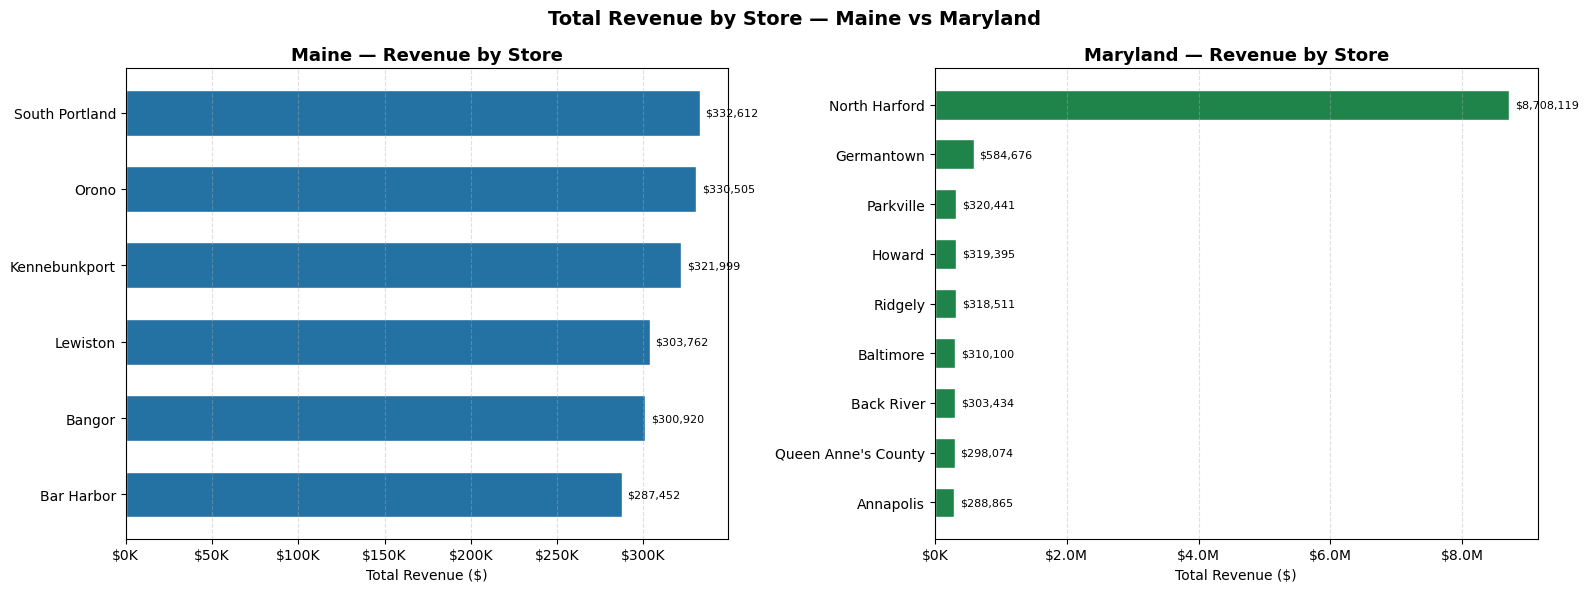

In [23]:
# Chart 2: Store Revenue Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Maine': '#2471A3', 'Maryland': '#1E8449'}

for i, state in enumerate(my_states):
    df = store_revenue[store_revenue['State'] == state].sort_values(
        'Total_Revenue', ascending=True)
    bars = axes[i].barh(
        df['Store Location'], df['Total_Revenue'],
        color=colors[state], edgecolor='white', height=0.6)
    axes[i].set_title(f'{state} — Revenue by Store',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Total Revenue ($)', fontsize=10)
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' 
                              if x >= 1e6 else f'${x/1e3:.0f}K'))
    for bar, val in zip(bars, df['Total_Revenue']):
        axes[i].text(val + (df['Total_Revenue'].max() * 0.01),
                     bar.get_y() + bar.get_height()/2,
                     f'${val:,.0f}', va='center', fontsize=8)
    axes[i].grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Total Revenue by Store — Maine vs Maryland',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_store_rankings.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved!")

# Question 4 — Top Customers by Territory

In [24]:
# Filter to transactions that have a RewardsID (loyalty members only)
rewards_sales = my_sales_detail[my_sales_detail['RewardsID'].notna()].copy()
rewards_sales['RewardsID'] = rewards_sales['RewardsID'].astype(int)

# Merge with customer list to get customer names
top_customers = rewards_sales.merge(
    customer_list[['cust_id', 'name']],
    left_on='RewardsID', right_on='cust_id',
    how='left'
)

# Group by territory and customer, sum total spend
cust_grouped = top_customers.groupby(
    ['State', 'name', 'RewardsID']).agg(
    Total_Spend=('Sale Amount', 'sum'),
    Num_Transactions=('Sale Amount', 'count')
).reset_index().sort_values(
    ['State', 'Total_Spend'], ascending=[True, False])

# Display top 10 customers per territory
for state in my_states:
    df = cust_grouped[cust_grouped['State'] == state].head(10).reset_index(drop=True)
    df.index += 1
    print(f"\n{'='*60}")
    print(f"  Top 10 Customers — {state}")
    print(f"{'='*60}")
    for idx, row in df.iterrows():
        print(f"  #{idx:<3} {row['name']:<25} "
              f"Spend: ${row['Total_Spend']:>9,.2f}  |  "
              f"Transactions: {row['Num_Transactions']}")


  Top 10 Customers — Maine
  #1   Rosita                    Spend: $ 3,637.75  |  Transactions: 5
  #2   Karen Walker              Spend: $ 3,362.83  |  Transactions: 3
  #3   Maddy Perez               Spend: $ 2,706.42  |  Transactions: 4
  #4   Mike H.                   Spend: $ 2,695.22  |  Transactions: 6
  #5   Philip Banks              Spend: $ 2,662.84  |  Transactions: 7
  #6   AJ Soprano                Spend: $ 2,574.08  |  Transactions: 3
  #7   Trent Lane                Spend: $ 2,558.21  |  Transactions: 3
  #8   Laura Palmer              Spend: $ 2,488.19  |  Transactions: 5
  #9   James Hurley              Spend: $ 2,482.78  |  Transactions: 5
  #10  Nipsey                    Spend: $ 2,112.13  |  Transactions: 4

  Top 10 Customers — Maryland
  #1   Cole Brown                Spend: $ 7,602.28  |  Transactions: 26
  #2   Donna Hayward             Spend: $ 7,081.17  |  Transactions: 24
  #3   Avon Barksdale            Spend: $ 6,172.68  |  Transactions: 27
  #4   Trent La

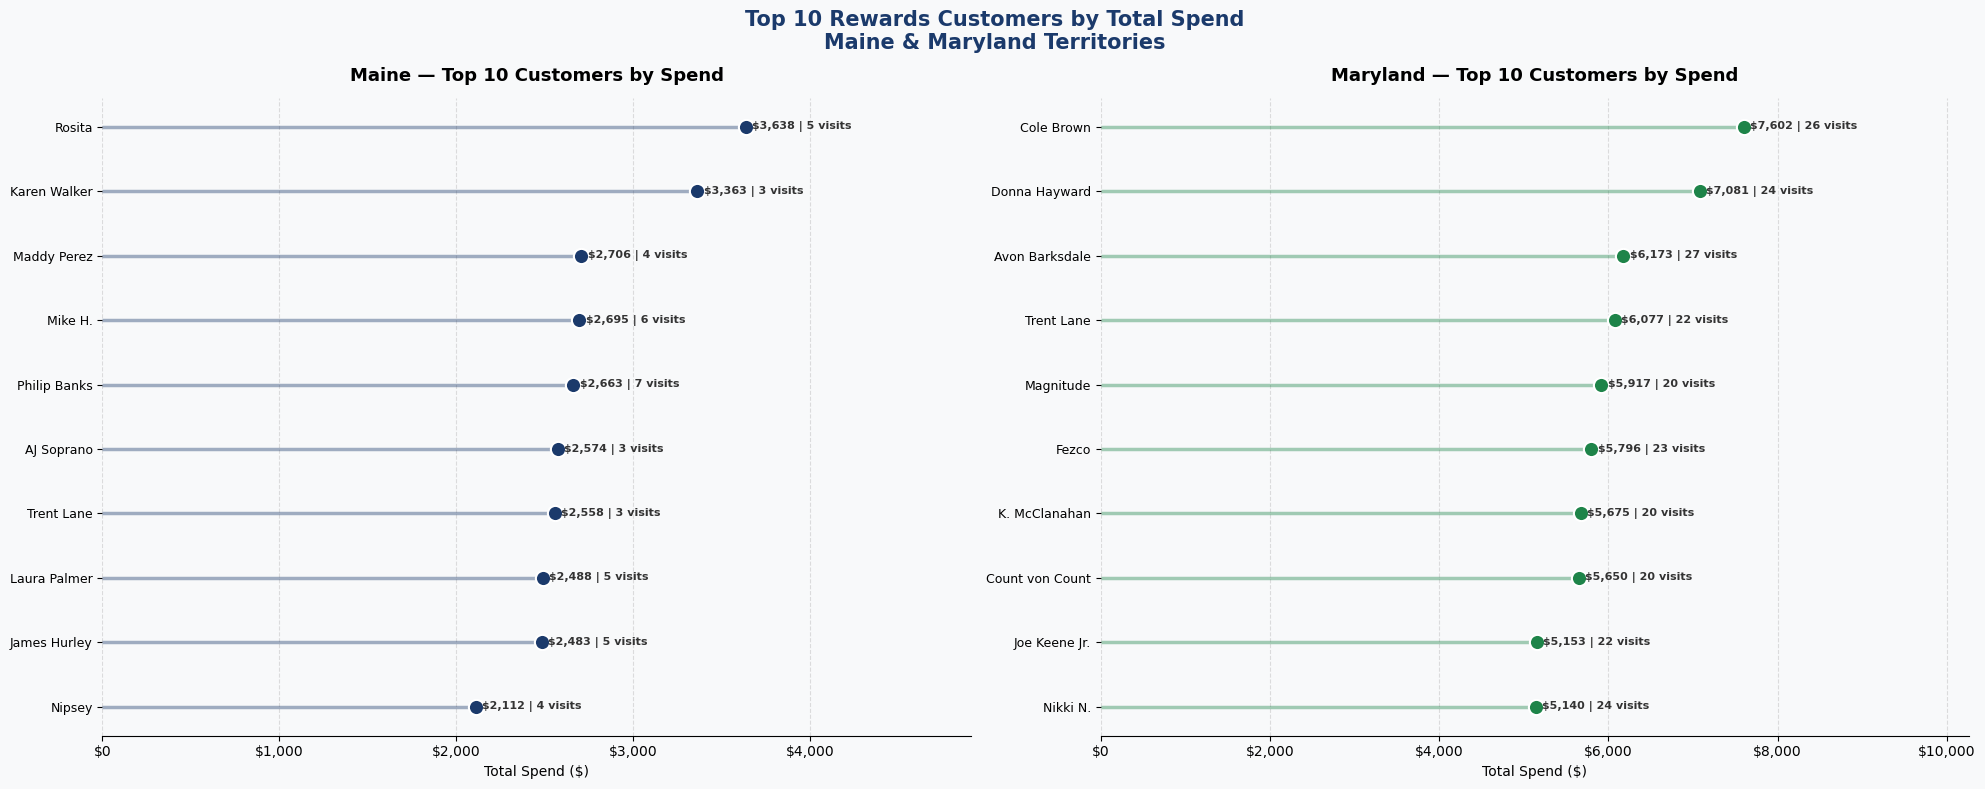

Chart saved!


In [33]:
# Chart 4: Lollipop Chart — Top 10 Customers
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#F8F9FA')
colors = {'Maine': '#1B3A6B', 'Maryland': '#1E8449'}

for col, state in enumerate(my_states):
    df = cust_grouped[cust_grouped['State'] == state].head(10).sort_values(
        'Total_Spend', ascending=True).reset_index(drop=True)
    color = colors[state]
    y = range(len(df))

    # Draw the lines (stems)
    axes[col].hlines(y=y, xmin=0, xmax=df['Total_Spend'],
                      color=color, alpha=0.4, linewidth=2.5)

    # Draw the circles (lollipop heads)
    axes[col].scatter(df['Total_Spend'], y,
                       color=color, s=120, zorder=3,
                       edgecolors='white', linewidth=1.5)

    # Customer name labels on y axis
    axes[col].set_yticks(y)
    axes[col].set_yticklabels(df['name'], fontsize=9)

    # Value labels next to each dot
    for i, (val, txn) in enumerate(zip(df['Total_Spend'],
                                        df['Num_Transactions'])):
        axes[col].text(val + df['Total_Spend'].max() * 0.01, i,
                       f'${val:,.0f} | {txn} visits',
                       va='center', fontsize=8,
                       color='#333333', fontweight='bold')

    axes[col].set_facecolor('#F8F9FA')
    axes[col].set_title(f'{state} — Top 10 Customers by Spend',
                         fontsize=13, fontweight='bold', pad=12)
    axes[col].set_xlabel('Total Spend ($)', fontsize=10)
    axes[col].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    axes[col].spines['top'].set_visible(False)
    axes[col].spines['right'].set_visible(False)
    axes[col].spines['left'].set_visible(False)
    axes[col].grid(axis='x', linestyle='--', alpha=0.4)
    axes[col].set_xlim(0, df['Total_Spend'].max() * 1.35)

plt.suptitle('Top 10 Rewards Customers by Total Spend\nMaine & Maryland Territories',
             fontsize=15, fontweight='bold', color='#1B3A6B')
plt.tight_layout()
plt.savefig('chart4_top_customers.png', bbox_inches='tight',
            dpi=150, facecolor='#F8F9FA')
plt.show()
print("Chart saved!")

In [25]:
# Merge sales with products to get category info
sales_products = my_sales_detail.merge(
    products[['Prod Num', 'CategoryID']], 
    on='Prod Num', how='left')

# Merge with product categories to get category names
sales_cat = sales_products.merge(
    product_categories[['CategoryID', 'Category']].drop_duplicates(),
    on='CategoryID', how='left')

# Group by territory and category
cat_summary = sales_cat.groupby(
    ['State', 'Category']).agg(
    Total_Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index().sort_values(
    ['State', 'Total_Revenue'], ascending=[True, False])

# Display results
for state in my_states:
    df = cat_summary[cat_summary['State'] == state]
    print(f"\n{'='*65}")
    print(f"  {state} — Revenue & Transactions by Category")
    print(f"{'='*65}")
    for _, row in df.iterrows():
        print(f"  {row['Category']:<35} "
              f"Revenue: ${row['Total_Revenue']:>12,.2f}  |  "
              f"Transactions: {row['Total_Transactions']:,}")


  Maine — Revenue & Transactions by Category
  Technology & Accessories            Revenue: $1,359,289.84  |  Transactions: 2,848
  Textbooks                           Revenue: $  309,330.88  |  Transactions: 1,800
  Apparel and Merchandise             Revenue: $   80,611.53  |  Transactions: 2,552
  Art Supplies                        Revenue: $   70,570.15  |  Transactions: 2,230
  Books (General)                     Revenue: $   29,730.25  |  Transactions: 1,050
  Stationery and Supplies             Revenue: $   27,717.10  |  Transactions: 2,763

  Maryland — Revenue & Transactions by Category
  Technology & Accessories            Revenue: $7,826,937.84  |  Transactions: 16,836
  Textbooks                           Revenue: $2,021,177.87  |  Transactions: 11,639
  Apparel and Merchandise             Revenue: $  500,587.47  |  Transactions: 15,547
  Books (General)                     Revenue: $  494,845.76  |  Transactions: 15,335
  Art Supplies                        Revenue: $  4

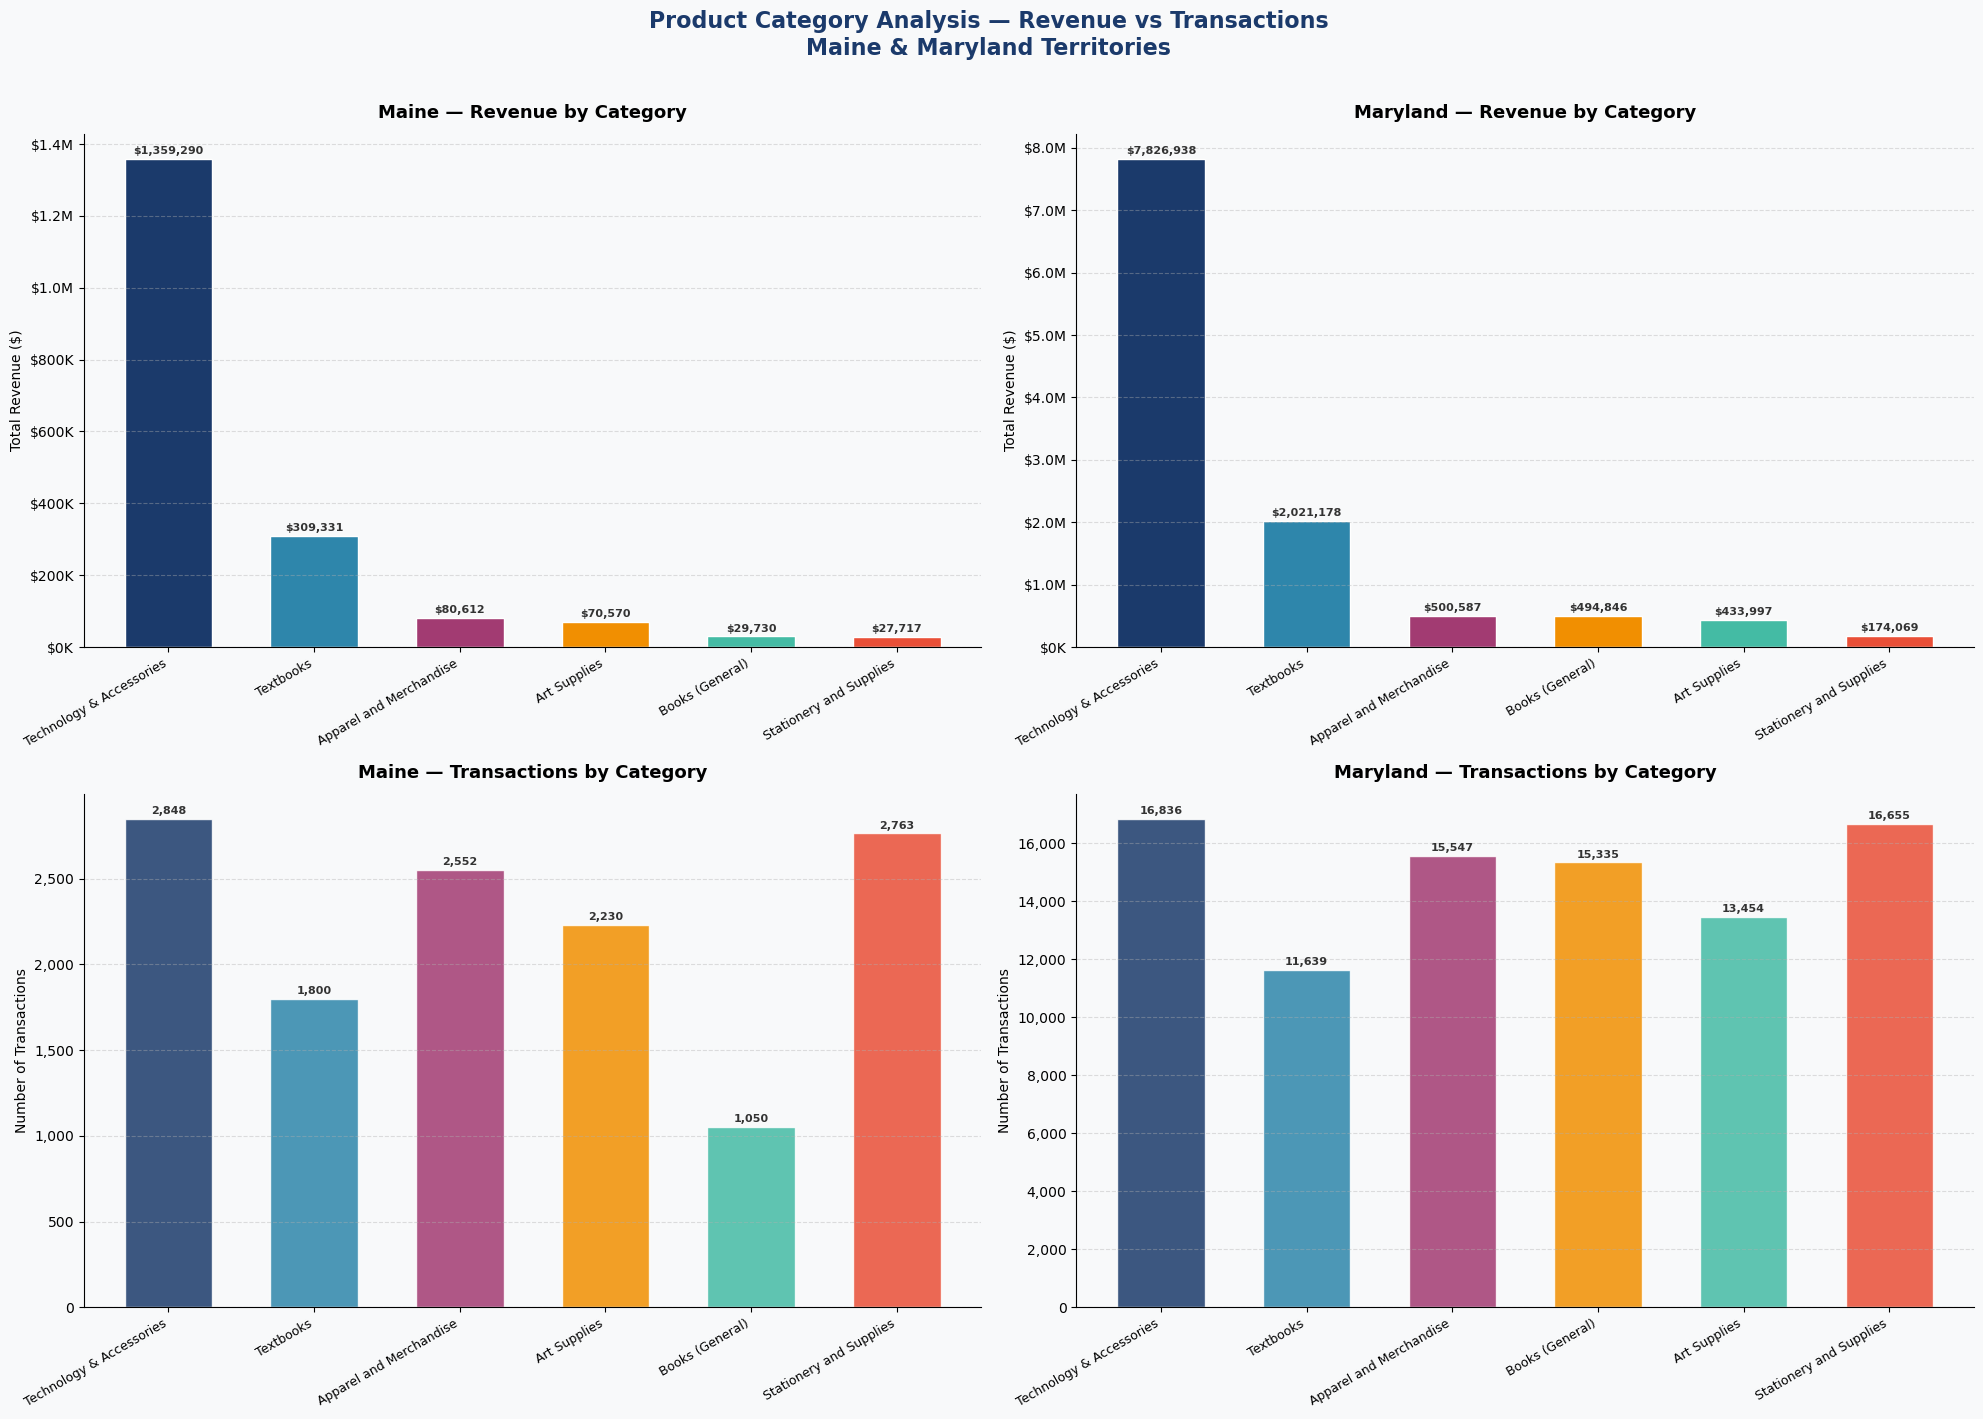

Chart saved!


In [29]:
# Chart 3: Revenue vs Transactions by Category — Professional Colors
import numpy as np

# Professional color palette per category
category_colors = [
    '#1B3A6B',  # Deep Navy
    '#2E86AB',  # Corporate Blue
    '#A23B72',  # Elegant Magenta
    '#F18F01',  # Warm Amber
    '#44BBA4',  # Teal
    '#E94F37',  # Professional Red
]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('#F8F9FA')

for col, state in enumerate(my_states):
    df = cat_summary[cat_summary['State'] == state].sort_values(
        'Total_Revenue', ascending=False)
    categories = df['Category'].tolist()
    revenues = df['Total_Revenue'].tolist()
    transactions = df['Total_Transactions'].tolist()
    x = np.arange(len(categories))

    # --- Top panel: Revenue by Category ---
    bars1 = axes[0, col].bar(x, revenues,
                              color=category_colors[:len(categories)],
                              edgecolor='white', width=0.6)
    axes[0, col].set_facecolor('#F8F9FA')
    axes[0, col].set_title(f'{state} — Revenue by Category',
                            fontsize=13, fontweight='bold', pad=12)
    axes[0, col].set_ylabel('Total Revenue ($)', fontsize=10)
    axes[0, col].set_xticks(x)
    axes[0, col].set_xticklabels(categories, rotation=30, 
                                  ha='right', fontsize=9)
    axes[0, col].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'
                              if v >= 1e6 else f'${v/1e3:.0f}K'))
    axes[0, col].grid(axis='y', linestyle='--', alpha=0.4)
    axes[0, col].spines['top'].set_visible(False)
    axes[0, col].spines['right'].set_visible(False)
    for bar, val in zip(bars1, revenues):
        axes[0, col].text(bar.get_x() + bar.get_width()/2,
                          bar.get_height() + max(revenues) * 0.01,
                          f'${val:,.0f}', ha='center', fontsize=8,
                          fontweight='bold', color='#333333')

    # --- Bottom panel: Transactions by Category ---
    bars2 = axes[1, col].bar(x, transactions,
                              color=category_colors[:len(categories)],
                              edgecolor='white', width=0.6, alpha=0.85)
    axes[1, col].set_facecolor('#F8F9FA')
    axes[1, col].set_title(f'{state} — Transactions by Category',
                            fontsize=13, fontweight='bold', pad=12)
    axes[1, col].set_ylabel('Number of Transactions', fontsize=10)
    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(categories, rotation=30,
                                  ha='right', fontsize=9)
    axes[1, col].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    axes[1, col].grid(axis='y', linestyle='--', alpha=0.4)
    axes[1, col].spines['top'].set_visible(False)
    axes[1, col].spines['right'].set_visible(False)
    for bar, val in zip(bars2, transactions):
        axes[1, col].text(bar.get_x() + bar.get_width()/2,
                          bar.get_height() + max(transactions) * 0.01,
                          f'{val:,}', ha='center', fontsize=8,
                          fontweight='bold', color='#333333')

plt.suptitle('Product Category Analysis — Revenue vs Transactions\nMaine & Maryland Territories',
             fontsize=16, fontweight='bold', y=1.01, color='#1B3A6B')
plt.tight_layout()
plt.savefig('chart3_category_analysis.png', bbox_inches='tight', 
            dpi=150, facecolor='#F8F9FA')
plt.show()
print("Chart saved!")

**Key Observations:**
- **Technology & Accessories dominates** both territories in revenue — the clear #1 category by a wide margin
- **Stationery and Supplies** has the most transactions but lowest revenue — customers buy often but spend very little per visit
- **Textbooks** punch above their weight — fewer transactions but high revenue per purchase
- **Biggest opportunity:** Books (General) and Art Supplies have decent traffic but low revenue — targeted promotions could unlock growth